# **Análisis Exploratorio de Salarios en Data Science**

## Objetivo

Analizar los factores que influyen en los salarios dentro del área de Data Science a nivel global.

## Preguntas clave

- ¿Qué roles tienen los salarios más altos?
- ¿Cómo influye la experiencia?
- ¿Qué países pagan mejor?
- ¿Qué variables impactan más el salario?

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Carga de datos

In [16]:
df = pd.read_csv("../data/processed/ds_salaries_clean.csv", index_col=0)
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_usd,employee_residence,remote_ratio,company_location,company_size,salary_category,job_category,continent
0,2020,Mid,Full-time,Data Scientist,70000,EUR,79833,DE,0,DE,L,Medium,Data Scientist,Europe
1,2020,Senior,Full-time,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S,High,ML Engineer,Asia
2,2020,Senior,Full-time,Big Data Engineer,85000,GBP,109024,GB,50,GB,M,High,Data Engineer,Europe
3,2020,Mid,Full-time,Product Data Analyst,20000,USD,20000,HN,0,HN,S,Low,Data Analyst,Other
4,2020,Senior,Full-time,Machine Learning Engineer,150000,USD,150000,US,50,US,L,High,ML Engineer,North America


### Vista general del dataset

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 0 to 606
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_usd          607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
 11  salary_category     607 non-null    object
 12  job_category        607 non-null    object
 13  continent           607 non-null    object
dtypes: int64(4), object(10)
memory usage: 71.1+ KB


In [18]:
df.describe()

,work_year,salary,salary_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


### Distribución del salario

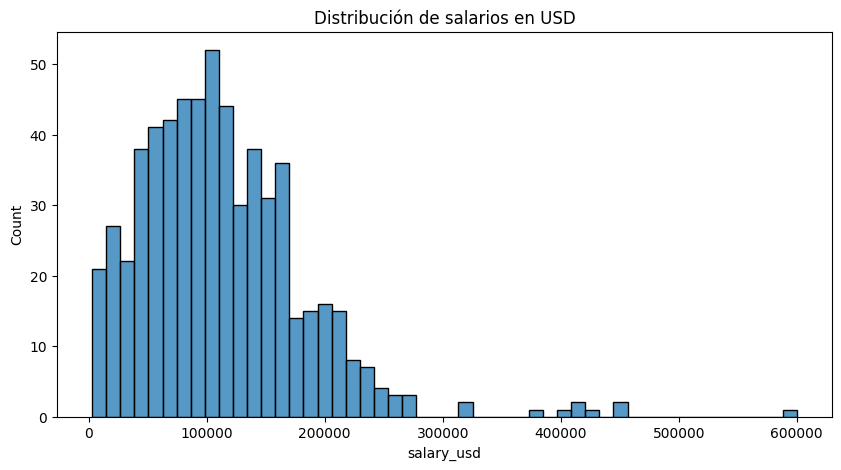

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(df["salary_usd"], bins=50)
plt.title("Distribución de salarios en USD")
plt.show()

La distribución muestra que la mayoría de salarios se concentran en rangos medios (entre $100,000 a $150,000), con una cola hacia salarios altos ($400,000).

### Salario por nivel de experiencia

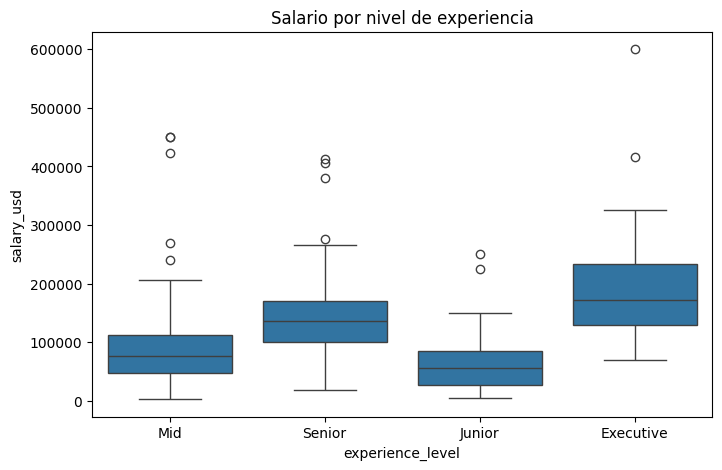

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x="experience_level", y="salary_usd", data=df)
plt.title("Salario por nivel de experiencia")
plt.show()

El gráfico de cajas muestra que un Senior gana significativamente mas que un Junior, en comparación su dispersión es mas baja.

### Salario por rol

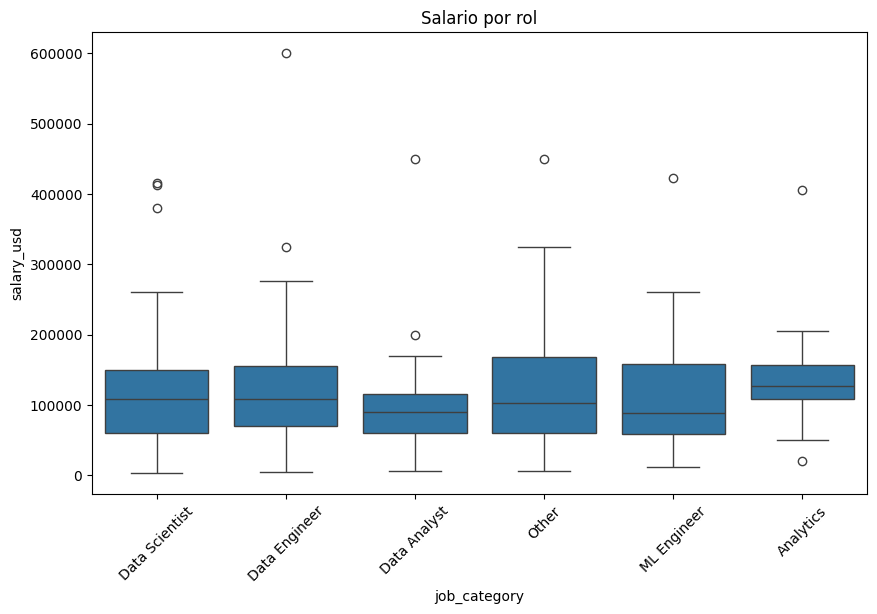

In [21]:
top_roles = df["job_category"].value_counts().index # categorizar en el etl

plt.figure(figsize=(10,6))
sns.boxplot(x="job_category", y="salary_usd", data=df, order=top_roles)
plt.xticks(rotation=45)
plt.title("Salario por rol")
plt.show()

Los roles mas técnicos como Data Scientis y Data Engineer tienden a concentrar mejores salarios base. El puesto de Data Engineer tiene una mayor variabilidad en sus salarios.

### Top países mejor pagados

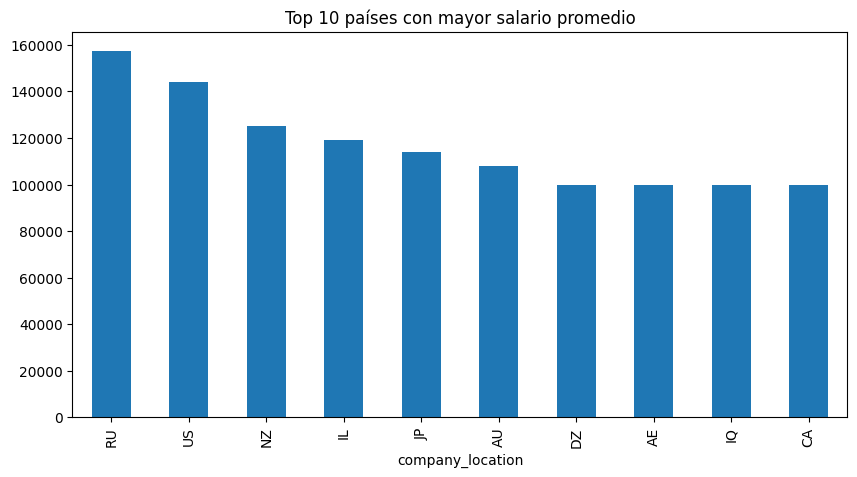

In [22]:
top_countries = df.groupby("company_location")["salary_usd"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind="bar")
plt.title("Top 10 países con mayor salario promedio")
plt.show()

El gráfico muestra una predominancia en los países asiáticos (Israel, Japón, Emiratos Árabes Unidos, Iraq y parte de Rusia) como los que mejor ofertan estas profesiones.

### Relación experiencia vs. salario

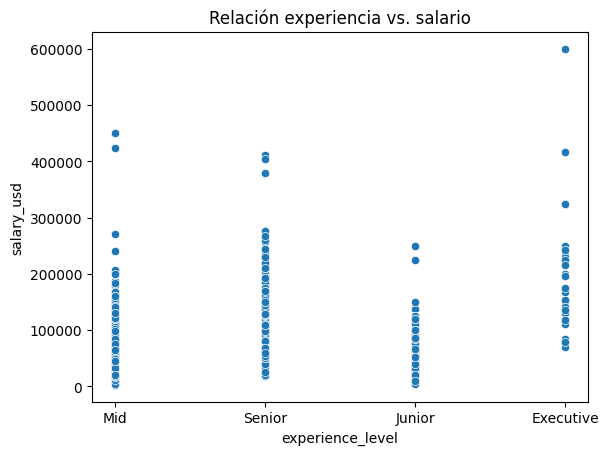

In [23]:
sns.scatterplot(x="experience_level", y="salary_usd", data=df)
plt.title("Relación experiencia vs. salario")
plt.show()

La dispersión muestra una clara predominancia y una concentración mayor en altos salarios para los perfiles Senior, incluso un poco por encima de los Executive.

### Heatmap de correlación

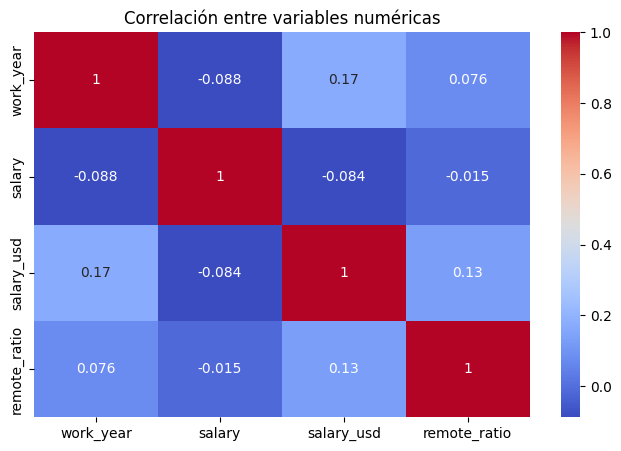

In [24]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()

- Los salarios han crecido con el tiempo pero no en gran cantidad.
- Los trabajos remotos no necesariamente pagan mucho más, aunque hay una pequeña tendencia.
- Se puede determinar que no hay relaciones lineales fuertes, el salario depende de múltiples factores combinados.

### Impacto del tipo de empleo

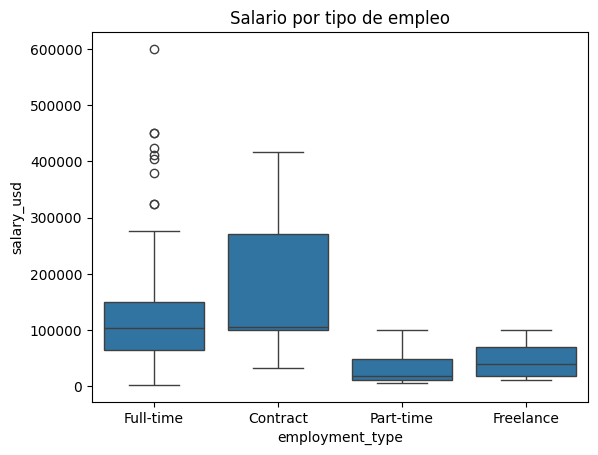

In [25]:
sns.boxplot(x="employment_type", y="salary_usd", data=df)
plt.title("Salario por tipo de empleo")
plt.show()

En este gráfico de cajas se demuestra que los perfiles que trabajan Full-time dominan claramente el mercado para estas profesiones.

### **Insights Clave**

- Los roles de Data Scientist y Data Engineer presentan los salarios más altos.
- La experiencia es uno de los factores más determinantes en el salario.
- Estados Unidos lidera en compensación promedio.
- Los empleos Full-time dominan el mercado y ofrecen mayor estabilidad salarial.
- Existe una alta variabilidad en salarios altos, indicando diferencias por empresa o especialización.